## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names")


## 2. Load data

In [2]:
df = pd.read_csv("vehicles.csv")
print(df.shape)


(426880, 26)


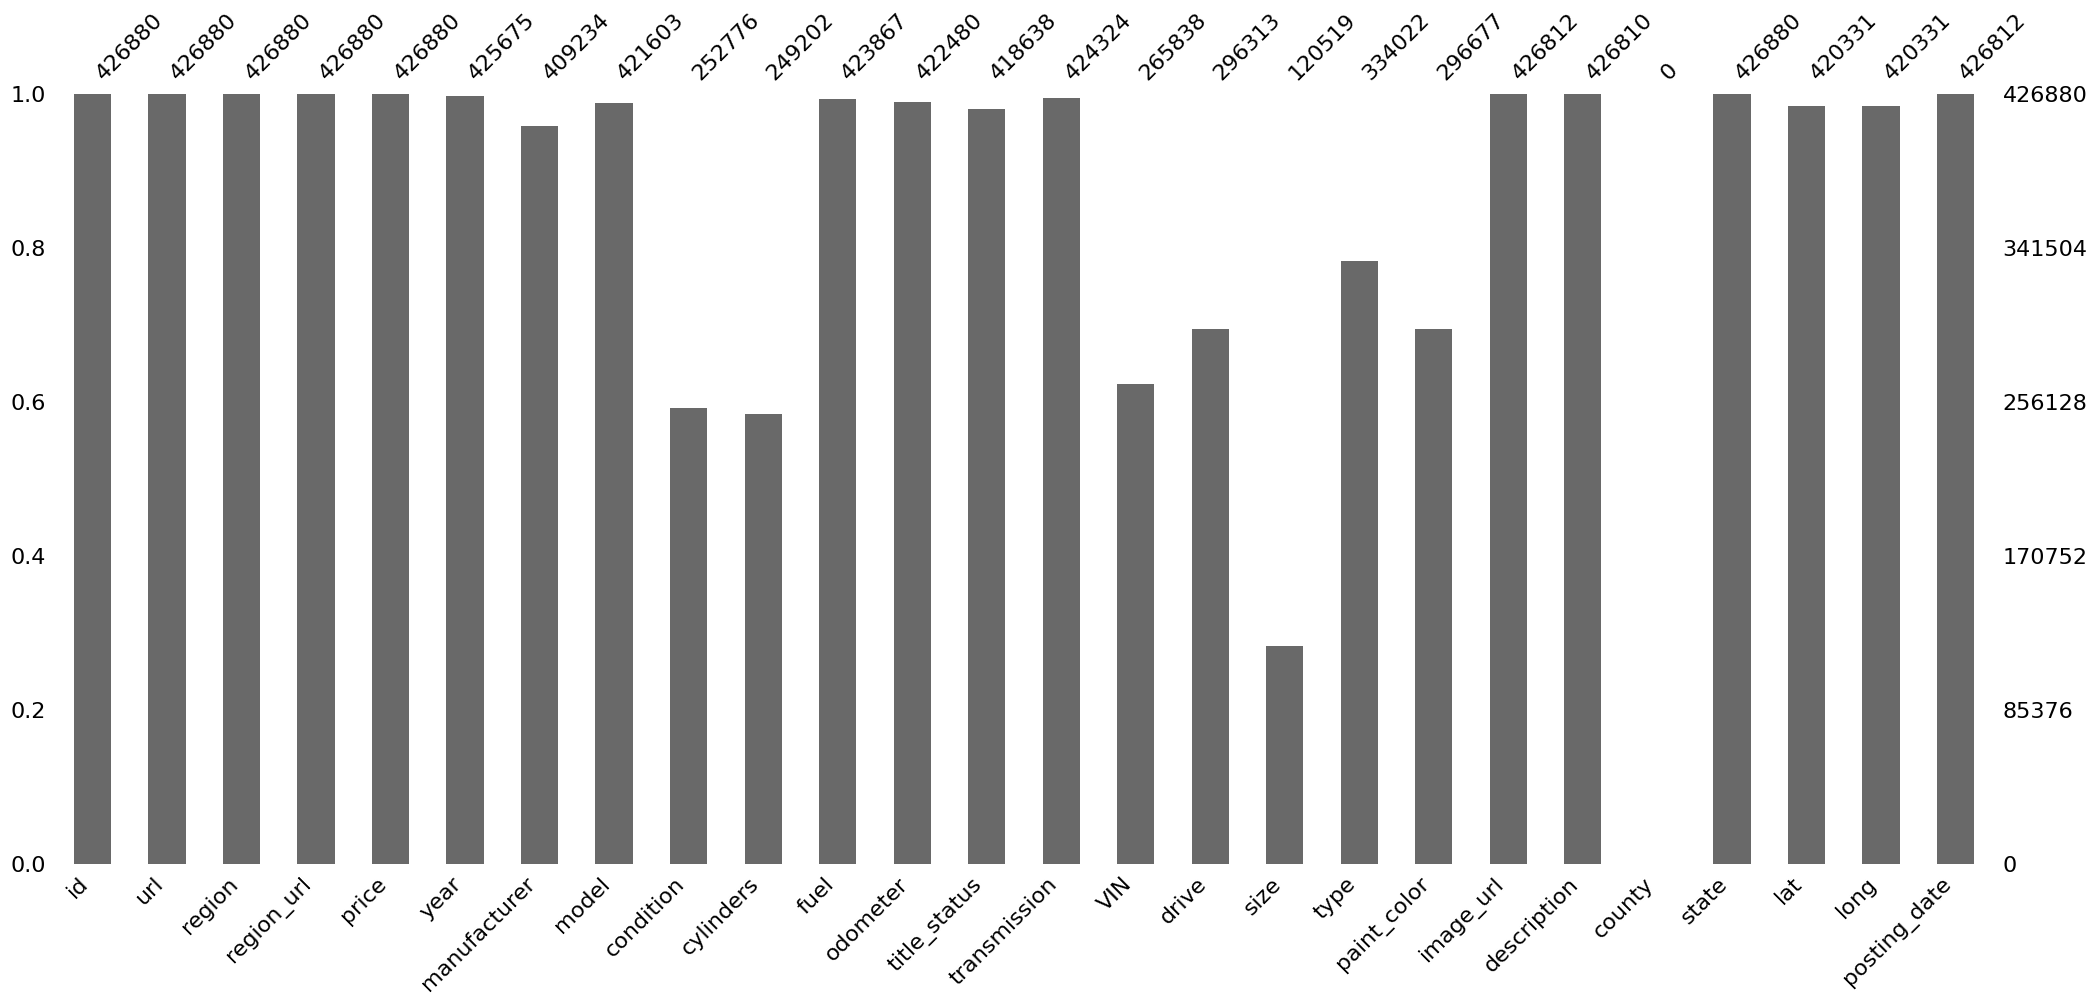

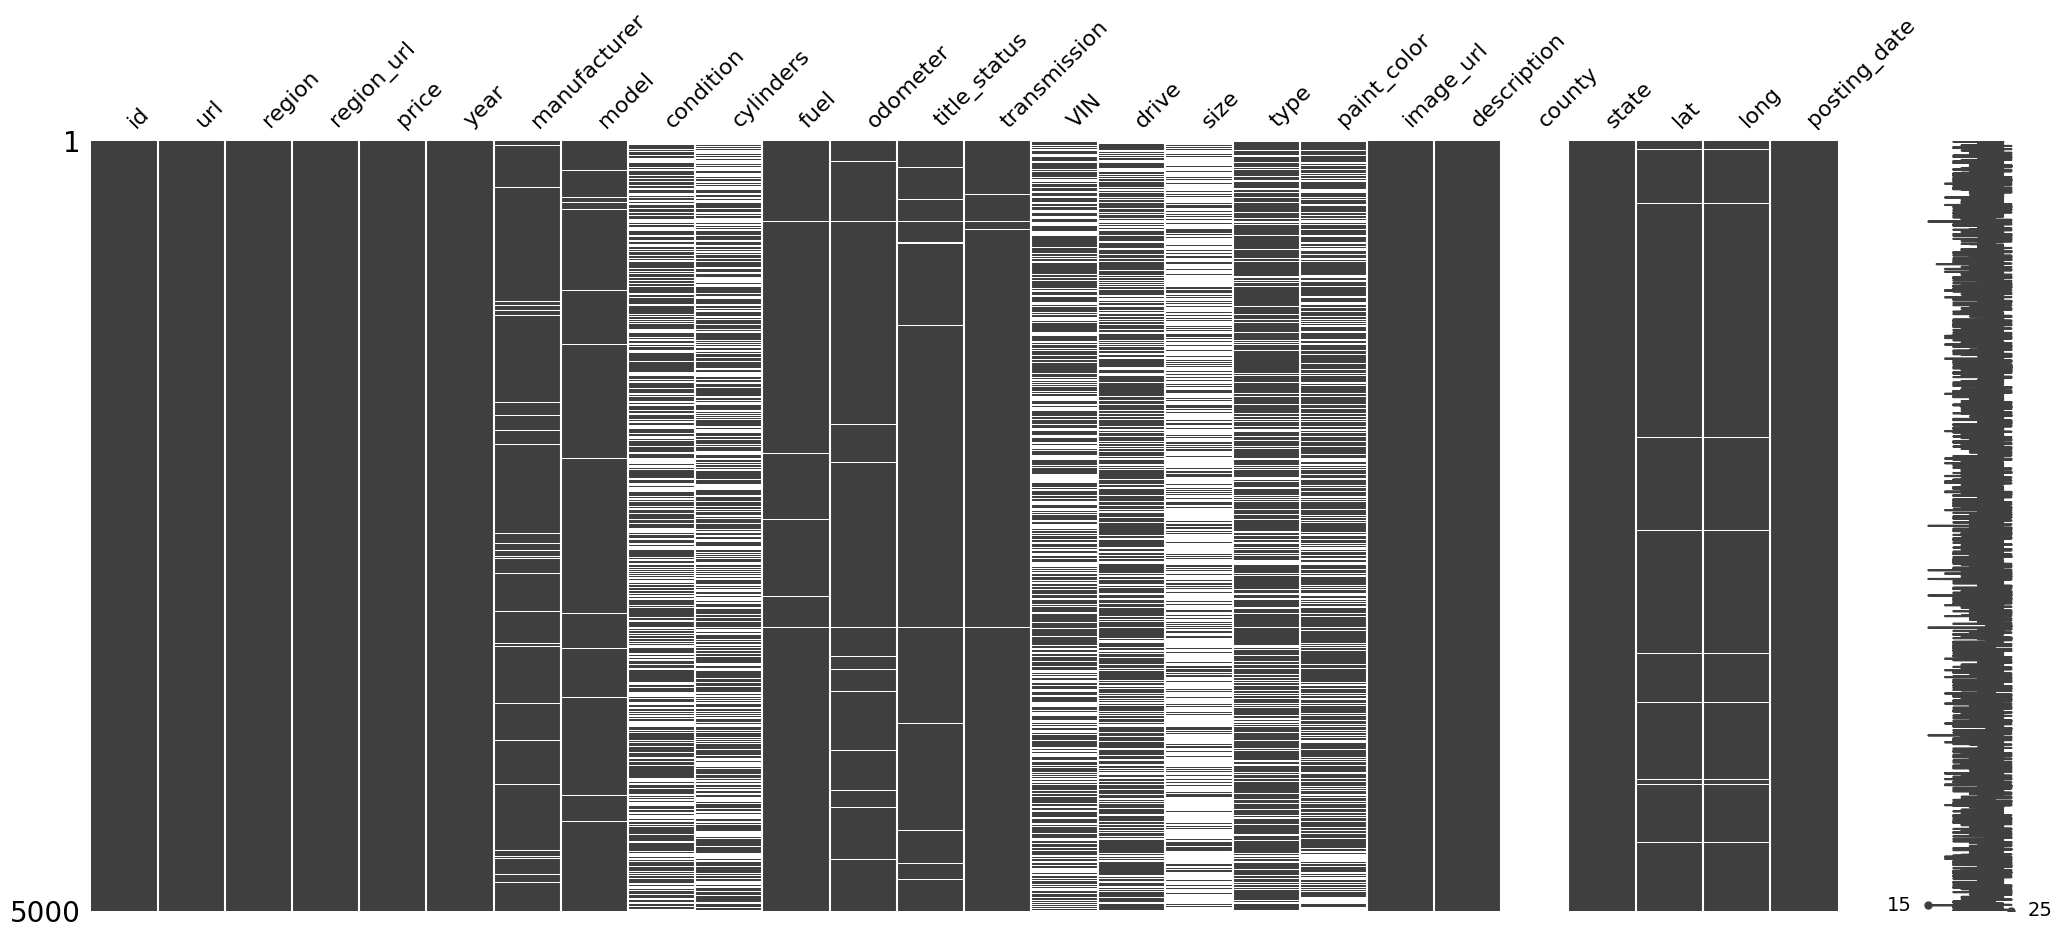

In [3]:
msno.bar(df)
plt.show()

msno.matrix(df.sample(5000, random_state=42))
plt.show()


## 3. Drop Unneeded Columns & Rows Without a Target

In [4]:
columns_to_drop = ['county', 'size', 'VIN', 'lat', 'long', 'image_url',
                   'description', 'region_url', 'url', 'id', 'posting_date']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


df = df.dropna(subset=['price'])


## 4. Train / Test Split

In [5]:
target_col = 'price'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (298816, 14)  Test: (128064, 14)


In [6]:
small_missing_cols = ['year', 'fuel', 'odometer', 'transmission', 'title_status']

def basic_dropna(frame_X, frame_y, cols):
    mask = frame_X[cols].notna().all(axis=1)
    return frame_X[mask].copy(), frame_y[mask].copy()

X_train, y_train = basic_dropna(X_train, y_train, small_missing_cols)
X_test, y_test = basic_dropna(X_test, y_test, small_missing_cols)

for frame in (X_train, X_test):
    frame['cylinders'] = frame['cylinders'].astype(str).str.extract(r'(\d+)')[0]
    frame['cylinders'] = pd.to_numeric(frame['cylinders'], errors='coerce')


group_modes = {}
for col in ['cylinders', 'drive', 'type']:
    modes = (
        X_train.groupby(['manufacturer', 'model'])[col]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    )
    group_modes[col] = modes

global_modes = {
    col: (X_train[col].mode().iloc[0] if not X_train[col].mode().empty else np.nan)
    for col in ['cylinders', 'drive', 'type']
}

def fill_group_mode(frame, col):
    key = list(zip(frame['manufacturer'], frame['model']))
    mapped = pd.Series(key, index=frame.index).map(group_modes[col].to_dict())
    filled = frame[col].fillna(mapped)

    filled = filled.fillna(global_modes[col])
    return filled

for frame in (X_train, X_test):
    for col in ['cylinders', 'drive', 'type']:
        frame[col] = fill_group_mode(frame, col)


for name, frame_pair in [('train', (X_train, y_train)), ('test', (X_test, y_test))]:
    pass

def final_dropna(frame_X, frame_y):
    mask = frame_X[['manufacturer', 'model', 'cylinders']].notna().all(axis=1)
    return frame_X[mask].copy(), frame_y[mask].copy()

X_train, y_train = final_dropna(X_train, y_train)
X_test, y_test = final_dropna(X_test, y_test)


condition_mode = X_train['condition'].mode().iloc[0]
for frame in (X_train, X_test):
    frame['condition_missing'] = frame['condition'].isna().astype(int)
    frame['condition'] = frame['condition'].fillna(condition_mode)


for frame in (X_train, X_test):
    frame['paint_color'] = frame['paint_color'].fillna('unknown')

print("Train shape after cleaning:", X_train.shape)
print("Test shape after cleaning :", X_test.shape)


Train shape after cleaning: (272742, 15)
Test shape after cleaning : (116862, 15)


In [7]:
def get_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


train_mask = (
    (y_train >= 500) & (y_train <= 150000)
    & (X_train['odometer'] < 400000)
    & (X_train['year'] >= 1995)
)
X_train, y_train = X_train[train_mask], y_train[train_mask]

test_mask = (
    (y_test >= 500) & (y_test <= 150000)
    & (X_test['odometer'] < 400000)
    & (X_test['year'] >= 1995)
)
X_test, y_test = X_test[test_mask], y_test[test_mask]


price_low, price_high = get_bounds(y_train)
odo_low, odo_high = get_bounds(X_train['odometer'])

def apply_iqr(X_frame, y_frame):
    mask = (
        (y_frame >= price_low) & (y_frame <= price_high)
        & (X_frame['odometer'] >= odo_low) & (X_frame['odometer'] <= odo_high)
    )
    return X_frame[mask], y_frame[mask]

X_train, y_train = apply_iqr(X_train, y_train)
X_test, y_test = apply_iqr(X_test, y_test)

print("Train after outlier removal:", X_train.shape)
print("Test after outlier removal :", X_test.shape)


Train after outlier removal: (233342, 15)
Test after outlier removal : (100110, 15)


In [8]:
def kfold_target_encode(X_train, y_train, X_test, cols, n_splits=5, smoothing=10, seed=42):
    global_mean = y_train.mean()
    X_train_enc = X_train.copy()
    X_test_enc = X_test.copy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for col in cols:
        oof = pd.Series(index=X_train.index, dtype=float)
        for tr_idx, val_idx in kf.split(X_train):
            tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
            stats = tr_y.groupby(tr_x[col]).agg(['mean', 'count'])
            smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
            oof.iloc[val_idx] = X_train[col].iloc[val_idx].map(smoothed).values
        oof = oof.fillna(global_mean)
        X_train_enc[col] = oof

      
        full_stats = y_train.groupby(X_train[col]).agg(['mean', 'count'])
        full_smoothed = (full_stats['mean'] * full_stats['count'] + global_mean * smoothing) / (full_stats['count'] + smoothing)
        X_test_enc[col] = X_test[col].map(full_smoothed).fillna(global_mean)

    return X_train_enc, X_test_enc

high_cardinality_cols = ['region', 'model']
X_train, X_test = kfold_target_encode(X_train, y_train, X_test, high_cardinality_cols)


In [9]:
num_cols = ['year', 'cylinders', 'odometer']
ordinal_cols = ['condition']
condition_ordering = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']
categ_cols = ['fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color']
passthrough_cols = ['condition_missing', 'region', 'model']  

all_pipeline = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', RobustScaler())]), num_cols),
    ('ord', Pipeline([('ordinal', OrdinalEncoder(
        categories=[condition_ordering], handle_unknown='use_encoded_value', unknown_value=-1
    ))]), ordinal_cols),
    ('cat', Pipeline([('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))]), categ_cols),
], remainder='passthrough')  


cols_order = num_cols + ordinal_cols + categ_cols + passthrough_cols
X_train_ord = X_train[cols_order]
X_test_ord = X_test[cols_order]

X_train_final = all_pipeline.fit_transform(X_train_ord, y_train)
X_test_final = all_pipeline.transform(X_test_ord)

print("Training data shape:", X_train_final.shape)
print("Test data shape    :", X_test_final.shape)


Training data shape: (233342, 44)
Test data shape    : (100110, 44)


In [10]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    print(f"\n==================== {name} ====================")
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"R2: {r2:.4f} | MAE: {mae:,.0f} | RMSE: {rmse:,.0f}")
    results[name] = {"r2": r2, "mae": mae, "rmse": rmse}

    train_sizes_cv, train_scores_cv, val_scores_cv = learning_curve(
        estimator=model, X=X_train_final, y=y_train,
        train_sizes=np.linspace(0.2, 1.0, 5), cv=3, scoring='r2', n_jobs=-1
    )
    train_mean, val_mean = train_scores_cv.mean(axis=1), val_scores_cv.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_cv, train_mean, 'o-', color='r', label='Training Score')
    plt.plot(train_sizes_cv, val_mean, 'o-', color='g', label='Cross-Validation Score')
    plt.title(f"Learning Curve ({name})")
    plt.xlabel("Number of Training Examples"); plt.ylabel("R2 Score")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    residuals = y_test - y_pred
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, ax=axes[0])
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([0, max_val], [0, max_val], 'r--')
    axes[0].set_title(f'Actual vs Predicted ({name})')

    sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='#9467bd')
    axes[1].set_title(f'Residuals Distribution ({name})')

    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, ax=axes[2], color='#2ca02c')
    axes[2].axhline(0, color='red', linestyle='--')
    axes[2].set_title(f'Residuals vs Predicted ({name})')
    plt.tight_layout(); plt.show()

pd.DataFrame(results).T



==================== Random Forest ====================
R2: 0.9034 | MAE: 2,163 | RMSE: 3,923


KeyboardInterrupt: 

In [11]:
model= XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

model.fit(X_train_final , y_train)

y=model.predict(X_test_final)
r2=r2_score(y_test , y)

In [12]:



joblib.dump(all_pipeline, 'preprocessing_pipeline.pkl')

model.save_model("XGBR.json")



In [13]:
import joblib

smoothing = 10
global_mean = float(y_train.mean())

encoding_maps = {
    "global_mean": global_mean,
    # global_modes was already computed in Cell 11
    "cylinders_fallback": float(global_modes["cylinders"]),
}

for col in ["region", "model"]:
    stats = y_train.groupby(X_train[col]).agg(["mean", "count"])
    smoothed = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
    encoding_maps[col] = smoothed.to_dict()

joblib.dump(encoding_maps, "encoding_maps.pkl")

print("Saved encoding_maps.pkl")
print("region categories :", len(encoding_maps["region"]))
print("model categories  :", len(encoding_maps["model"]))
print("global_mean        :", encoding_maps["global_mean"])
print("cylinders_fallback :", encoding_maps["cylinders_fallback"])

Saved encoding_maps.pkl
region categories : 2012
model categories  : 21727
global_mean        : 18585.592400853682
cylinders_fallback : 6.0
